# 1.2 — The Shape Zoo, at the computer

Do the **pen-and-paper worksheet first** — the sketching-by-hand is the actual training.
Here you verify your sketches, race the species against each other, and read your first loss curve.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions, axes_through_origin

/var/folders/lf/jdz4bcf14ts38vz0c1511rr80000gn/T/ipykernel_20413/1014472511.py:8: RuntimeWarning: invalid value encountered in log2
  "log: log₂(x)":        lambda x: np.log2(x),   # np.log2 = log base 2; np.log = base e


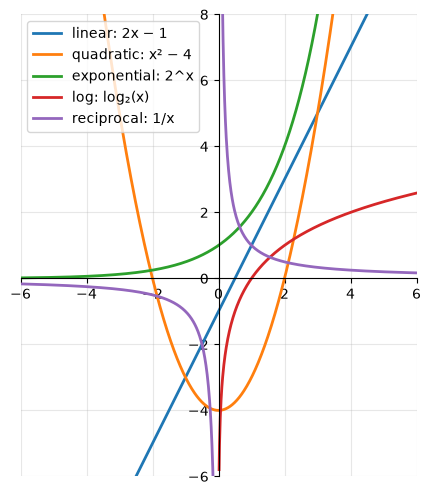

In [2]:
# The whole zoo on one set of axes. Check each against your Part B sketches:
# crossings right? asymptotes right? shape right?

plot_functions({
    "linear: 2x − 1":      lambda x: 2*x - 1,
    "quadratic: x² − 4":   lambda x: x**2 - 4,
    "exponential: 2^x":    lambda x: 2**x,
    "log: log₂(x)":        lambda x: np.log2(x),   # np.log2 = log base 2; np.log = base e
    "reciprocal: 1/x":     lambda x: 1/x,
}, xlim=(-6, 6), ylim=(-6, 8))
plt.show()

# (numpy politely warns about log of negatives and 1/0, then plots the legal parts.
#  The gaps in the log and reciprocal curves ARE their domains, drawn.)

## 1. The race: $x^2$ vs $2^x$

Worksheet problem 17 — who wins eventually? At $x = 2$ they tie (4 vs 4). At $x = 4$ they tie
again (16 vs 16). Then it stops being polite:

In [3]:
for x in [2, 4, 6, 10, 20, 30]:
    print(f"x = {x:>2}:   x² = {x**2:>12,}    2^x = {2**x:>15,}")

# f"..." is an f-string: it drops values into text. {x:>2} means right-align in 2 spaces;
# the , adds thousands separators. Handy for tables like this.

# THIS is why 'exponential growth' is a warning and not a description.
# Where the x sits — base or exponent — is a species barrier.

x =  2:   x² =            4    2^x =               4
x =  4:   x² =           16    2^x =              16
x =  6:   x² =           36    2^x =              64
x = 10:   x² =          100    2^x =           1,024
x = 20:   x² =          400    2^x =       1,048,576
x = 30:   x² =          900    2^x =   1,073,741,824


## 2. The exp/log mirror

$\log_2 x$ is $2^x$ with question and answer swapped. Swapping input and output reflects a graph
across the diagonal $y = x$. See it:

/var/folders/lf/jdz4bcf14ts38vz0c1511rr80000gn/T/ipykernel_20413/2915302105.py:3: RuntimeWarning: invalid value encountered in log2
  "y = log₂(x)": lambda x: np.log2(x),


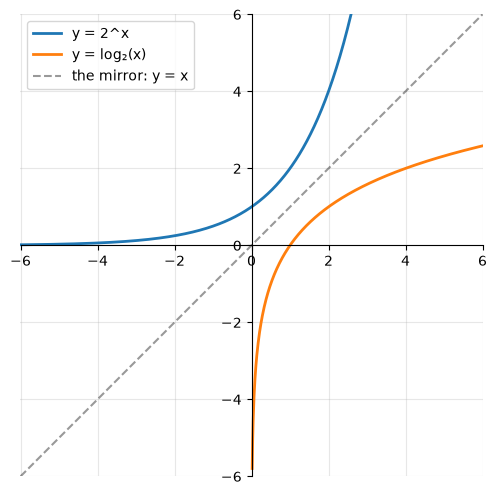

In [4]:
ax = plot_functions({
    "y = 2^x":     lambda x: 2**x,
    "y = log₂(x)": lambda x: np.log2(x),
}, xlim=(-6, 6), ylim=(-6, 6))
ax.plot([-6, 6], [-6, 6], "k--", alpha=0.4, label="the mirror: y = x")
ax.legend(loc="upper left")
plt.show()

# One explodes, one flattens — same information, opposite temperament.
# This is why logs tame explosive things: they're the explosion, run in reverse.

## 3. Your first loss curve

When a model trains, its error over time traces a shape from the zoo. Below is a realistic
loss curve: exponential decay ($e^{-x}$, the falling slide) plus a bit of noise, because real
training is bumpy.

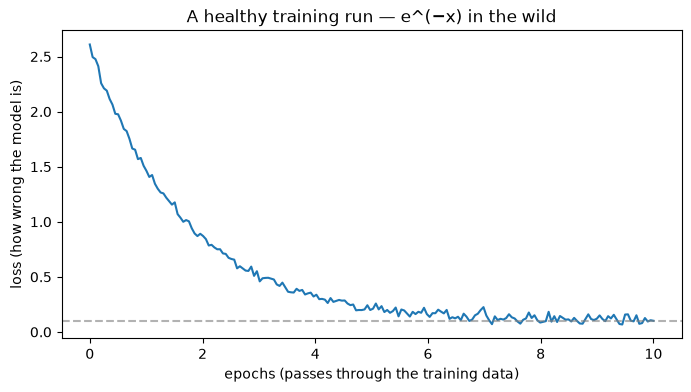

In [5]:
rng = np.random.default_rng(42)          # a seeded random generator: same 'random' every run
epochs = np.linspace(0, 10, 200)
loss = 2.5 * np.exp(-0.6 * epochs) + 0.1 + rng.normal(0, 0.03, size=200)

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss, linewidth=1.5)
plt.axhline(0.1, color="gray", linestyle="--", alpha=0.6)   # the floor it's creeping toward
plt.xlabel("epochs (passes through the training data)")
plt.ylabel("loss (how wrong the model is)")
plt.title("A healthy training run — e^(−x) in the wild")
plt.show()

# You will stare at hundreds of these. You now know its species on sight:
# exponential decay toward an asymptote. The dashed floor is 'as good as this model gets'.

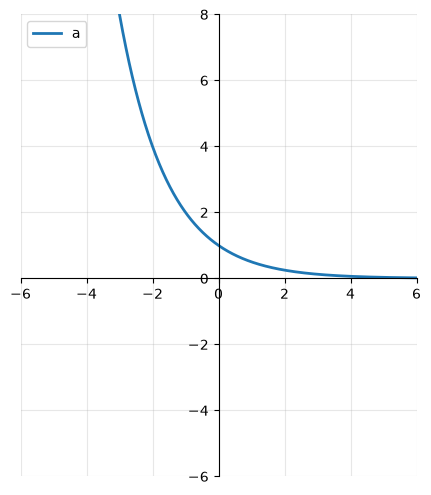

In [6]:
# YOUR TURN — before running: write down (on your worksheet, next to Part D) the species and
# shape you expect for each of these three. THEN run and score yourself.
#
#   a) y = 2^(-x)
#   b) y = -x² + 4
#   c) y = 1/(x − 2)      <- worksheet problem 18: where did the crash site move?

plot_functions({
    "a": lambda x: 2.0**(-x),
    # "b": ...,          # <- add machine b yourself
    # "c": ...,          # <- and c  (write it as 1/(x - 2))
}, xlim=(-6, 6), ylim=(-6, 8))
plt.show()

## Score yourself honestly

Species right? End-behaviour right? Asymptotes dashed and in the right place?
Wherever paper-you disagreed with matplotlib, that's a review-queue item — tell Claude.

---
*Done? Photograph your worksheet into `scans/inbox/`.
Next: 1.3 — transforming graphs: what weights and biases actually DO.*